# 03 - Preparação dos Dados

Nos notebooks anteriores entendi o problema e explorei a base. Agora preciso
deixar os dados prontos para a modelagem.

Neste notebook eu:

- tiro colunas que não posso usar (identificadores, informação do resultado
  final e informação que só aparece depois da reserva);
- trato valores estranhos (`adr`, reservas sem hóspedes);
- crio algumas variáveis novas a partir das que já existem;
- separo os dados em treino e teste usando a data de chegada.

O que eu **não** faço aqui é preencher ausentes com média/mediana, padronizar
ou aplicar one-hot. Isso aprende algo a partir dos dados e vai dentro de um
pipeline ajustado só no treino, no próximo notebook. No fim eu junto toda a
limpeza em `src/preprocessing.py`, para os outros notebooks e o app usarem o
mesmo tratamento sem repetir código.

## 1. Bibliotecas e dados

In [1]:
import sys
sys.path.append("..")   # para importar src/ (o notebook roda dentro de notebooks/)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/josepharroyoh/hotel-cancellation-ml/main/data/raw/hotel_booking.csv"
)

df = pd.read_csv(DATA_URL)
df.shape

(119390, 36)

## 2. O que trago dos notebooks anteriores

- o alvo é `is_canceled` (0 = não cancelada, 1 = cancelada), com cerca de 37% de cancelamentos;
- `reservation_status` e `reservation_status_date` revelam o resultado da reserva;
- `name`, `email`, `phone-number` e `credit_card` são identificadores artificiais;
- `company` tem 94% de ausentes e `agent` tem 14%;
- `adr` tem um valor negativo e valores muito altos;
- existem reservas com 0 hóspedes e com 0 noites;
- depois de tirar os identificadores aparecem linhas repetidas.

## 3. Colunas de identificação

Foram acrescentadas na versão do Kaggle e não descrevem a reserva. Removo.

In [3]:
identificadores = ["name", "email", "phone-number", "credit_card"]
df = df.drop(columns=identificadores)
df.shape

(119390, 32)

### Linhas repetidas

Depois de tirar os identificadores, várias linhas ficam iguais. Vejo quantas
são e como se comportam.

In [4]:
repetidas = df.drop(columns=["reservation_status", "reservation_status_date"]).duplicated(keep=False)

print("Linhas em algum grupo repetido:", repetidas.sum(), f"({repetidas.mean() * 100:.1f}%)")
print("Cancelamento nas repetidas:    ", round(df.loc[repetidas, "is_canceled"].mean(), 3))
print("Cancelamento nas não repetidas:", round(df.loc[~repetidas, "is_canceled"].mean(), 3))

Linhas em algum grupo repetido: 40448 (33.9%)
Cancelamento nas repetidas:     0.587
Cancelamento nas não repetidas: 0.26


As linhas repetidas cancelam bem mais que as demais. Mesmo assim não vou
removê-las: a base não tem um identificador de reserva, então duas linhas
iguais podem ser reservas diferentes (por exemplo dois quartos reservados
juntos), e como elas concentram cancelamentos, removê-las mudaria a proporção
do alvo. Deixo registrado e testo de novo no notebook 07.

## 4. Colunas que revelam o resultado

`reservation_status` diz direto se a reserva terminou em cancelamento, no-show
ou check-out. `reservation_status_date` é a data desse desfecho. Nenhuma das
duas estaria disponível no momento da previsão.

In [5]:
pd.crosstab(df["reservation_status"], df["is_canceled"])

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


In [6]:
df = df.drop(columns=["reservation_status", "reservation_status_date"])
df.shape

(119390, 30)

## 5. Informações que mudam depois da reserva

Três colunas podem ser preenchidas ou alteradas depois que a reserva foi feita:

- `assigned_room_type`: o quarto atribuído pode mudar até o check-in;
- `booking_changes`: conta alterações feitas ao longo do tempo;
- `days_in_waiting_list`: dias em lista de espera antes da confirmação.

In [7]:
mudou_quarto = df["assigned_room_type"] != df["reserved_room_type"]
print("Quarto atribuído diferente do reservado:", f"{mudou_quarto.mean() * 100:.1f}%")
print("  cancelamento quando mudou:    ", round(df.loc[mudou_quarto, "is_canceled"].mean(), 3))
print("  cancelamento quando não mudou:", round(df.loc[~mudou_quarto, "is_canceled"].mean(), 3))

Quarto atribuído diferente do reservado: 12.5%
  cancelamento quando mudou:     0.054
  cancelamento quando não mudou: 0.416


Quando o quarto é trocado quase não há cancelamento: o cliente apareceu. É
informação de depois da reserva. Removo as três.

In [8]:
df = df.drop(columns=["assigned_room_type", "booking_changes", "days_in_waiting_list"])
df.shape

(119390, 27)

## 6. Valores ausentes

In [9]:
ausentes = df.isnull().sum()
ausentes[ausentes > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

### company e agent

`company` tem 94% de ausentes, não dá para usar como categoria. Mas a
presença de uma empresa é informativa. Guardo isso como um indicador 0/1 e
removo a coluna. Faço o mesmo indicador para `agent` (o ausente costuma ser
reserva feita direto), mas o código da agência eu mantenho como categoria.

In [10]:
tem_empresa = df["company"].notna()
tem_agencia = df["agent"].notna()
print("cancelamento com empresa:", round(df.loc[tem_empresa, "is_canceled"].mean(), 3),
      " / sem empresa:", round(df.loc[~tem_empresa, "is_canceled"].mean(), 3))
print("cancelamento com agência:", round(df.loc[tem_agencia, "is_canceled"].mean(), 3),
      " / sem agência:", round(df.loc[~tem_agencia, "is_canceled"].mean(), 3))

df["has_company"] = tem_empresa.astype(int)
df["has_agent"] = tem_agencia.astype(int)
df = df.drop(columns=["company"])

cancelamento com empresa: 0.175  / sem empresa: 0.382
cancelamento com agência: 0.39  / sem agência: 0.247


### children e country

`children` tem 4 ausentes, preencho com 0. `country` tem 488 ausentes (menos
de 0,5%); trato mais abaixo, junto com o agrupamento de categorias.

In [11]:
df["children"] = df["children"].fillna(0)

## 7. Tarifa média diária (adr)

In [12]:
df["adr"].describe(percentiles=[0.01, 0.5, 0.99])

count   119390.00
mean       101.83
std         50.54
min         -6.38
1%           0.00
50%         94.58
99%        252.00
max       5400.00
Name: adr, dtype: float64

In [13]:
print("adr negativo:", (df["adr"] < 0).sum())
print("adr > 1000:  ", (df["adr"] > 1000).sum())
print("adr = 0:     ", (df["adr"] == 0).sum())
df.loc[df["adr"] == 0, "market_segment"].value_counts().head()

adr negativo: 1
adr > 1000:   1
adr = 0:      1959


market_segment
Complementary    680
Online TA        367
Offline TA/TO    332
Groups           252
Direct           240
Name: count, dtype: int64

- um valor negativo (-6,38): erro, removo a linha;
- um valor de 5400, muito acima do segundo maior (perto de 510): trato como
  erro de digitação e limito o `adr` em 1000;
- 1959 reservas com `adr = 0`: a maioria é do segmento *Complementary*
  (cortesias). São reais, mantenho.

In [14]:
df = df[df["adr"] >= 0].copy()
df["adr"] = df["adr"].clip(upper=1000)
df.shape

(119389, 28)

## 8. Reservas com 0 hóspedes e com 0 noites

In [15]:
hospedes = df["adults"] + df["children"] + df["babies"]
noites = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

print("0 hóspedes:", (hospedes == 0).sum(),
      "| cancelamento:", round(df.loc[hospedes == 0, "is_canceled"].mean(), 3))
print("0 noites:  ", (noites == 0).sum(),
      "| cancelamento:", round(df.loc[noites == 0, "is_canceled"].mean(), 3))

0 hóspedes: 180 | cancelamento: 0.139
0 noites:   715 | cancelamento: 0.049


Reserva com 0 hóspedes não é uma reserva de verdade (180 linhas). Removo.
Reserva com 0 noites (715) quase não cancela e pode ser uso durante o dia;
mantenho, com uma marca `zero_nights`.

In [16]:
df = df[hospedes > 0].copy().reset_index(drop=True)
df.shape

(119209, 28)

## 9. Datas

Junto ano, mês e dia numa data de chegada só, e estimo a data da reserva
subtraindo o `lead_time`.

In [17]:
meses = ["January", "February", "March", "April", "May", "June", "July",
         "August", "September", "October", "November", "December"]
mes_num = {nome: i for i, nome in enumerate(meses, start=1)}

df["arrival_date"] = pd.to_datetime(dict(
    year=df["arrival_date_year"],
    month=df["arrival_date_month"].map(mes_num),
    day=df["arrival_date_day_of_month"],
))
df["booking_date"] = df["arrival_date"] - pd.to_timedelta(df["lead_time"], unit="D")

print("Chegada:", df["arrival_date"].min().date(), "a", df["arrival_date"].max().date())
print("Reserva:", df["booking_date"].min().date(), "a", df["booking_date"].max().date())

Chegada: 2015-07-01 a 2017-08-31


Reserva: 2013-06-24 a 2017-08-31


## 10. Variáveis novas

Só combinações de colunas que já existem. Não trazem informação de fora.

In [18]:
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["has_previous_cancellation"] = (df["previous_cancellations"] > 0).astype(int)
df["zero_nights"] = (df["total_nights"] == 0).astype(int)

df["arrival_dow"] = df["arrival_date"].dt.dayofweek.astype(str)
df["booking_month"] = df["booking_date"].dt.month.astype(str)
df["booking_dow"] = df["booking_date"].dt.dayofweek.astype(str)

df[["total_nights", "total_guests", "has_previous_cancellation", "zero_nights"]].head()

,total_nights,total_guests,has_previous_cancellation,zero_nights
0,0,2.00,0,1
1,0,2.00,0,1
2,1,1.00,0,0
3,1,1.00,0,0
4,2,2.00,0,0


Motivo de cada uma: `total_nights` e `total_guests` resumem o tamanho da
reserva; `has_previous_cancellation` separa quem já cancelou antes (na EDA
esse grupo cancelou muito mais); `zero_nights` marca as reservas sem diária;
`arrival_dow`, `booking_month` e `booking_dow` captam sazonalidade e o efeito
do momento da reserva.

## 11. country e agent têm muitas categorias

Antes de codificar, vou ver quantos valores diferentes têm as duas colunas
que preocupam.

In [19]:
print("country:", df["country"].nunique(), "valores diferentes")
print(df["country"].value_counts().head(8))
print()
print("agent:", df["agent"].nunique(), "valores diferentes")
print(df["agent"].value_counts().head(8))

country: 177 valores diferentes
country
PRT    48483
GBR    12119
FRA    10401
ESP     8560
DEU     7285
ITA     3761
IRL     3374
BEL     2342
Name: count, dtype: int64

agent: 333 valores diferentes
agent
9.00      31922
240.00    13922
1.00       7187
14.00      3633
7.00       3532
6.00       3290
250.00     2870
241.00     1721
Name: count, dtype: int64


`country` tem 178 valores e `agent` tem 333, mas a maioria aparece em poucas
reservas. Se eu aplicasse one-hot direto, teria centenas de colunas quase
vazias.

Decisão: mantenho só as categorias com pelo menos 200 reservas e junto o
resto em `"outro"`. Para `agent`, o ausente vira `"nenhum"` (reserva feita
direto). Assim cada coluna vira dezenas de categorias em vez de centenas, sem
perder as que realmente aparecem.

In [20]:
df["agent"] = df["agent"].astype("Int64").astype("string").fillna("nenhum")
df["country"] = df["country"].fillna("outro")

for col in ["country", "agent"]:
    freq = df[col].value_counts()
    comuns = freq[freq >= 200].index
    df[col] = df[col].where(df[col].isin(comuns), "outro").astype(str)

print("country agora:", df["country"].nunique(), "| agent agora:", df["agent"].nunique())

country agora: 31 | agent agora: 57


## 12. Variáveis que entram no modelo

Separo em numéricas e categóricas. `arrival_date_year` fica de fora: como a
divisão é por tempo, o teste é quase todo de 2017 e o ano não ajudaria o
modelo a generalizar.

In [21]:
numericas = [
    "lead_time", "arrival_date_week_number", "arrival_date_day_of_month",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies",
    "is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled",
    "required_car_parking_spaces", "total_of_special_requests",
    "adr", "total_nights", "total_guests",
    "has_previous_cancellation", "zero_nights", "has_company", "has_agent",
]

categoricas = [
    "hotel", "arrival_date_month", "meal", "country",
    "market_segment", "distribution_channel",
    "reserved_room_type", "deposit_type", "customer_type", "agent",
    "arrival_dow", "booking_month", "booking_dow",
]

print("numéricas:", len(numericas), "| categóricas:", len(categoricas),
      "| total:", len(numericas + categoricas))

numéricas: 20 | categóricas: 13 | total: 33


## 13. Divisão em treino e teste

Quero uma divisão parecida com o uso real: treinar com o histórico e prever
reservas futuras. Por isso a divisão é **por tempo, não aleatória**.

Testo duas formas de ordenar antes de cortar 80% / 20%.

In [22]:
def taxa_por_parte(ordem):
    n = len(ordem)
    corte = int(n * 0.8)
    treino, teste = ordem[:corte], ordem[corte:]
    return {"treino": round(df.loc[treino, "is_canceled"].mean(), 3),
            "teste": round(df.loc[teste, "is_canceled"].mean(), 3)}

por_reserva = taxa_por_parte(df.sort_values("booking_date").index.to_numpy())
por_chegada = taxa_por_parte(df.sort_values(["arrival_date", "booking_date"]).index.to_numpy())

pd.DataFrame({"ordenado por booking_date": por_reserva, "ordenado por arrival_date": por_chegada})

,ordenado por booking_date,ordenado por arrival_date
treino,0.39,0.36
teste,0.32,0.41


Ordenando pela data da reserva, o teste fica com uma taxa de cancelamento
bem menor que o treino. Isso é um artefato: a base termina em agosto de 2017,
então as reservas antecipadas feitas no fim do período (que mais cancelam)
não estão na base. Ordenando pela data de chegada as taxas ficam mais
próximas. Uso a data de chegada.

In [23]:
from src.preprocessing import separar_treino_teste

df = df.sort_values(["arrival_date", "booking_date"]).reset_index(drop=True)
treino, teste = separar_treino_teste(df)

print(f"treino: {len(treino):>6}  ({treino['is_canceled'].mean():.3f})  "
      f"chegada {treino['arrival_date'].min().date()} a {treino['arrival_date'].max().date()}")
print(f"teste : {len(teste):>6}  ({teste['is_canceled'].mean():.3f})  "
      f"chegada {teste['arrival_date'].min().date()} a {teste['arrival_date'].max().date()}")

treino:  95367  (0.361)  chegada 2015-07-01 a 2017-04-22
teste :  23842  (0.409)  chegada 2017-04-22 a 2017-08-31


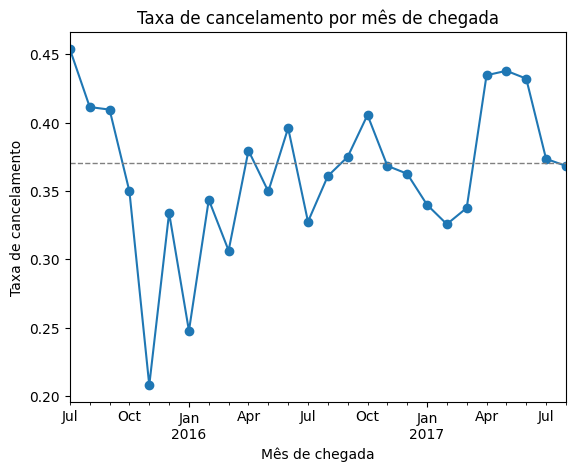

In [24]:
por_mes = df.groupby(df["arrival_date"].dt.to_period("M"))["is_canceled"].mean()
por_mes.plot(marker="o")
plt.axhline(df["is_canceled"].mean(), color="gray", linestyle="--", linewidth=1)
plt.title("Taxa de cancelamento por mês de chegada")
plt.xlabel("Mês de chegada")
plt.ylabel("Taxa de cancelamento")
plt.show()

A taxa de cancelamento sobe um pouco nos meses finais (chegadas de
abril–junho de 2017 cancelam mais). Por isso o teste, que é o período final,
tem taxa um pouco maior que o treino. É uma diferença sazonal, não um
problema da divisão.

Para escolher o limiar de decisão e calibrar as probabilidades, no notebook
06 vou separar uma parte final do próprio treino, já que não posso usar o
teste para isso.

## 14. Consolidação em src/preprocessing.py

Juntei toda a limpeza acima nas funções de `src/preprocessing.py`
(`preparar()` e `separar_treino_teste()`). Os notebooks 04 a 10 e o app
importam essas funções. Aqui confirmo que o resultado bate com o que fiz à mão.

In [25]:
from src.preprocessing import preparar

df_src = preparar()
print("mesma quantidade de linhas:", len(df_src) == len(df))
print("mesmas colunas:", sorted(df_src.columns) == sorted(df.columns))

mesma quantidade de linhas: True
mesmas colunas: True


## 15. O que levo para o próximo notebook

In [26]:
print(f"base final:           {len(df):,} reservas")
print(f"variáveis de entrada: {len(numericas + categoricas)} "
      f"({len(numericas)} numéricas, {len(categoricas)} categóricas)")
print(f"cancelamentos:        {df['is_canceled'].mean() * 100:.1f}%")
print(f"treino / teste:       {len(treino):,} / {len(teste):,}")

base final:           119,209 reservas
variáveis de entrada: 33 (20 numéricas, 13 categóricas)
cancelamentos:        37.1%
treino / teste:       95,367 / 23,842


- a base está limpa e com as variáveis novas, mas ainda sem imputação,
  encoding ou padronização (isso vira um pipeline no notebook 04, ajustado só
  no treino);
- a divisão é temporal por data de chegada, 80% treino e 20% teste;
- `country` e `agent` foram agrupados para não gerar centenas de colunas;
- as linhas repetidas foram mantidas e serão testadas de novo no notebook 07;
- `reservation_status`, `assigned_room_type`, `booking_changes` e
  `days_in_waiting_list` ficaram de fora por data leakage.

No notebook 04 começo a modelagem: um baseline e os primeiros modelos, com
métricas adequadas para classes desbalanceadas.